#  Assignment: K-Nearest Neighbors (KNN) Algorithm

### 🎓 Coursework Assignment — University of Gujrat

**Student Name:** `Muhammad Ali Saagar`

**Topic:** `K-Nearest Neighbors (KNN) & Evaluation Metrics`

---

##  Assignment Overview

This notebook presents the implementation and analysis of the **K-Nearest Neighbors (KNN)** algorithm as part of the coursework assignment at the **University of Gujrat**.

The assignment focuses on understanding how the **KNN algorithm** works, implementing it using Python and machine learning libraries, and evaluating its performance using different **evaluation metrics**.

###  Topics Covered

-  K-Nearest Neighbors (KNN)
-  Model Implementation
-  Model Evaluation
-  Evaluation Metrics
-  Performance Analysis

---

> **Prepared by:** `Muhammad Ali Saagar`
> **University of Gujrat — Coursework Assignment**

# KNN Assignment Notebook

This notebook implements:

- Dataset splitting using train_test_split
- KNN Algorithm (Class-based)
- KNN Algorithm (Procedural)
- Real-life KNN Scenarios
- Distance Metrics (Euclidean, Manhattan, Minkowski)

I used synthetic dataset for:

1. Student Pass Prediction (Classification)
2. GPA Prediction (Regression)

## Install Required Libraries

In [1]:
!pip install numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Creating Student Lifestyle Dataset

 I  generated 400 student records with:

- Study Hours
- Sleep Hours
- Screen Time
- Coffee Intake
- Attendance %

### Targets

Dataset 1 → Pass / Fail (Classification)  
Dataset 2 → GPA (Regression)

In [3]:
np.random.seed(42)

n = 400

study_hours = np.random.uniform(1, 10, n)
sleep_hours = np.random.uniform(3, 9, n)
screen_time = np.random.uniform(1, 8, n)
coffee = np.random.uniform(0, 5, n)
attendance = np.random.uniform(50, 100, n)

gpa = (
    0.4 * study_hours +
    0.2 * sleep_hours -
    0.2 * screen_time -
    0.1 * coffee +
    0.3 * (attendance/20)
)

gpa = np.clip(gpa, 0, 4)

pass_fail = (gpa >= 2).astype(int)
# astype for converting to binay values , if gpa is greater than 2 , it will return True and due to astype , it is converted to 1 ;  

data = pd.DataFrame({
    "StudyHours": study_hours,
    "SleepHours": sleep_hours,
    "ScreenTime": screen_time,
    "CoffeeIntake": coffee,
    "Attendance": attendance,
    "GPA": gpa,
    "Pass": pass_fail
})

data.head()

,StudyHours,SleepHours,ScreenTime,CoffeeIntake,Attendance,GPA,Pass
0,4.370861,3.618743,5.950670,3.791316,59.593366,1.796728,0
1,9.556429,8.415317,2.067773,0.122935,66.168578,4.000000,1
2,7.587945,6.031514,5.034019,0.110618,61.332820,4.000000,1
3,6.387926,7.958745,5.247005,1.618051,67.749815,3.951961,1
4,2.404168,4.920298,3.968915,2.443216,53.471192,1.709690,0


In [4]:
data.shape

(400, 7)

## Creating Two Datasets

Dataset 1 → Pass Prediction (Classification)

Dataset 2 → GPA Prediction (Regression)

In [5]:
X = data[["StudyHours", "SleepHours", "ScreenTime", "CoffeeIntake", "Attendance"]]

Y_class = data["Pass"]   # Classification
Y_reg = data["GPA"]      # Regression

## Data Visualization

 Visualize relationships between:

- Study Hours vs GPA
- Sleep Hours vs GPA
- Study Hours vs Pass/Fail

 

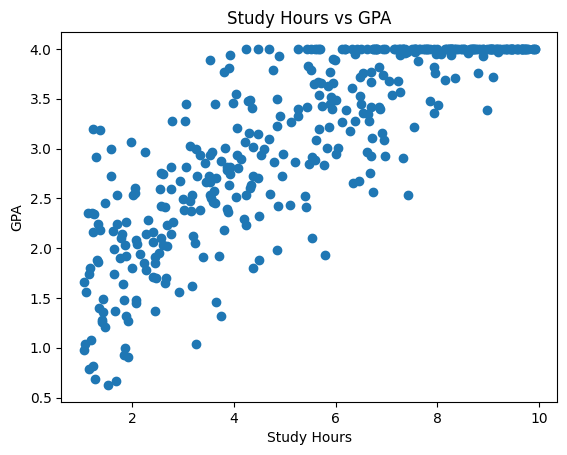

In [6]:
plt.scatter(data["StudyHours"], data["GPA"])
plt.xlabel("Study Hours")
plt.ylabel("GPA")
plt.title("Study Hours vs GPA")
plt.show()

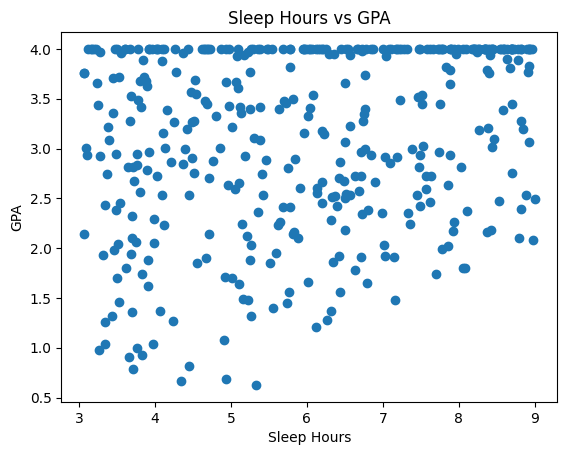

In [7]:
plt.scatter(data["SleepHours"], data["GPA"])
plt.xlabel("Sleep Hours")
plt.ylabel("GPA")
plt.title("Sleep Hours vs GPA")
plt.show()

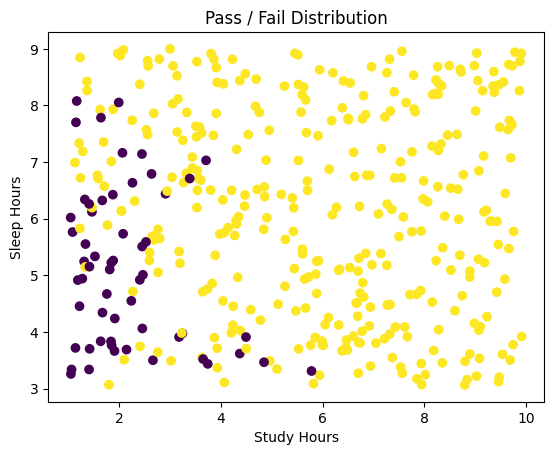

In [8]:
plt.scatter(data["StudyHours"], data["SleepHours"], c=data["Pass"])
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Pass / Fail Distribution")
plt.show()

# Q1 — Splitting Dataset into Training and Testing Sets


- 80% Training
- 20% Testing
 

## Splitting Dataset for Classification (Pass Prediction)

In [9]:
Train_X_c, Test_X_c, Train_Y_c, Test_Y_c = train_test_split(
    X, Y_class, test_size=0.2, random_state=42
)

### Training and Testing Samples (Classification)

In [10]:
print("Train_X (Classification)")
print(Train_X_c.head())

print("\nTrain_Y (Classification)")
print(Train_Y_c.head())

print("\nTest_X (Classification)")
print(Test_X_c.head())

print("\nTest_Y (Classification)")
print(Test_Y_c.head())
# print(len(Test_Y_c))

Train_X (Classification)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
3      6.387926    7.958745    5.247005      1.618051   67.749815
18     4.887505    7.035111    1.383331      3.272556   77.889171
202    2.454658    4.062063    7.110621      0.183357   67.662570
250    3.650040    3.521522    7.122912      2.485874   64.295339
274    5.602082    5.462381    7.914057      1.635166   86.640077

Train_Y (Classification)
3      1
18     1
202    0
250    0
274    1
Name: Pass, dtype: int64

Test_X (Classification)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
209    2.447272    7.142369    4.425975      4.341356   54.919782
280    9.010048    7.902432    6.504415      4.089171   84.444265
33     9.539970    3.606736    2.234709      0.155670   89.772498
210    5.938604    3.235873    2.548466      1.029206   83.015136
93     6.051495    4.128727    3.780285      3.447325   57.318700

Test_Y (Classification)
209    0
280    1
33     1
210    1
9

## Splitting Dataset for Regression (GPA Prediction)

In [11]:
Train_X_r, Test_X_r, Train_Y_r, Test_Y_r = train_test_split(
    X, Y_reg, test_size=0.2, random_state=42
)

### Training and Testing Samples (Regression)

In [12]:
print("Train_X (Regression)")
print(Train_X_r.head())

print("\nTrain_Y (Regression)")
print(Train_Y_r.head())

print("\nTest_X (Regression)")
print(Test_X_r.head())

print("\nTest_Y (Regression)")
print(Test_Y_r.head())

Train_X (Regression)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
3      6.387926    7.958745    5.247005      1.618051   67.749815
18     4.887505    7.035111    1.383331      3.272556   77.889171
202    2.454658    4.062063    7.110621      0.183357   67.662570
250    3.650040    3.521522    7.122912      2.485874   64.295339
274    5.602082    5.462381    7.914057      1.635166   86.640077

Train_Y (Regression)
3      3.951961
18     3.926440
202    1.368755
250    1.455581
274    2.886582
Name: GPA, dtype: float64

Test_X (Regression)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
209    2.447272    7.142369    4.425975      4.341356   54.919782
280    9.010048    7.902432    6.504415      4.089171   84.444265
33     9.539970    3.606736    2.234709      0.155670   89.772498
210    5.938604    3.235873    2.548466      1.029206   83.015136
93     6.051495    4.128727    3.780285      3.447325   57.318700

Test_Y (Regression)
209    1.911849
2

In [13]:
print("Classification Train Size:", len(Train_X_c))
print("Classification Test Size:", len(Test_X_c))

print("Regression Train Size:", len(Train_X_r))
print("Regression Test Size:", len(Test_X_r))

Classification Train Size: 320
Classification Test Size: 80
Regression Train Size: 320
Regression Test Size: 80


# Q2 — KNN Algorithm (Class-Based Implementation)

Implementing KNN using OOP.

We will also visualize feature space using:

Study Hours vs Sleep Hours

In [14]:
class KNN:

    def __init__(self, k=3):
        self.k = k

    def fit(self, X, Y):
        self.X_train = X.values
        self.Y_train = Y.values

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2)**2))

    def predict(self, X):
        predictions = []
        for test_point in X.values:

            distances = []

            for train_point in self.X_train:
                dist = self.euclidean_distance(test_point, train_point)
                distances.append(dist)
        #    find nearest K points , it gives the indices of sorted distances , 
            # distance ly ga (list hogi to indices b hon gy ), unko sort kry ga , ab jo  after sorted indices milein gy wo k_indices ma jayen wo b 3 , bcz k=3
            k_indices = np.argsort(distances)[:self.k]
            # get their labels
            k_labels = self.Y_train[k_indices]
            # majority vote
            # set(k_labels) = A class or B class   ,   key = count of each 
            prediction = max(set(k_labels), key=list(k_labels).count)
            predictions.append(prediction)

        return np.array(predictions)

In [15]:
knn_model = KNN(k=3)
knn_model.fit(Train_X_c, Train_Y_c)

predictions_class = knn_model.predict(Test_X_c)
predictions_class[:10]

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 1])

## Feature Space Visualization (Class-Based KNN)

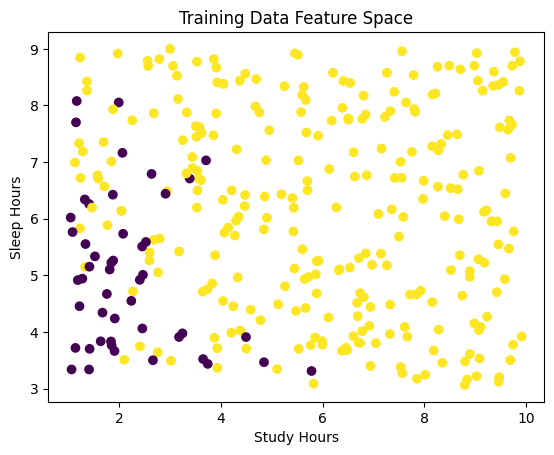

In [16]:
plt.scatter(Train_X_c["StudyHours"], Train_X_c["SleepHours"], c=Train_Y_c)
                                                            # c = class labels → used to color the points
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Training Data Feature Space")
plt.show()

# Q3 — KNN Algorithm (Procedural Implementation)

Now we implement KNN using functions instead of class.

In [17]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

In [18]:
def knn_predict(X_train, Y_train, X_test, k=3):

    predictions = []

    X_train = X_train.values
    Y_train = Y_train.values

    for test_point in X_test.values:

        distances = []

        for train_point in X_train:
            dist = euclidean_distance(test_point, train_point)
            distances.append(dist)

        k_indices = np.argsort(distances)[:k]
        k_labels = Y_train[k_indices]

        prediction = max(set(k_labels), key=list(k_labels).count)
        predictions.append(prediction)

    return np.array(predictions)

In [19]:
predictions_proc = knn_predict(Train_X_c, Train_Y_c, Test_X_c, k=3)
predictions_proc[:10]

array([0, 1, 1, 1, 1, 1, 0, 1, 1, 1])

## Feature Space Visualization (Procedural KNN)

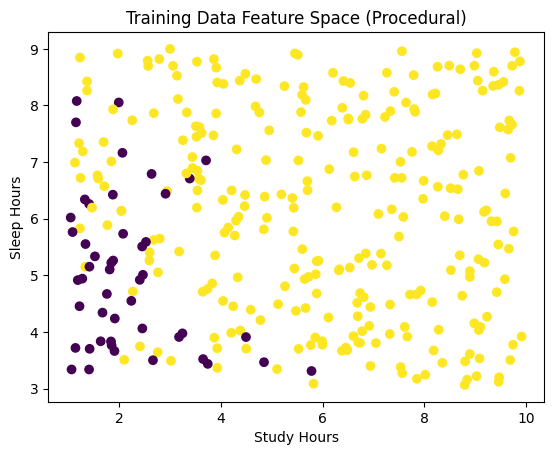

In [20]:
plt.scatter(Train_X_c["StudyHours"], Train_X_c["SleepHours"], c=Train_Y_c)
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Training Data Feature Space (Procedural)")
plt.show()

# Q4 — Scholarship Eligibility Prediction

Predict whether a student is eligible for scholarship based on:

- Study Hours
- Sleep Hours
- Attendance

Eligible = 1 if GPA > 3

In [21]:
scholarship = (data["GPA"] > 3).astype(int)

X_q4 = data[["StudyHours", "SleepHours", "Attendance"]]
Y_q4 = scholarship

Train_X_q4, Test_X_q4, Train_Y_q4, Test_Y_q4 = train_test_split(
    X_q4, Y_q4, test_size=0.2, random_state=42
)

pred_q4 = knn_predict(Train_X_q4, Train_Y_q4, Test_X_q4, k=3)
pred_q4[:10]

array([0, 1, 1, 0, 1, 0, 0, 1, 0, 1])

# Q5 — Healthy Lifestyle Prediction

Healthy if:

Sleep > 6 AND Screen Time < 4

In [22]:
healthy = ((data["SleepHours"] > 6) & (data["ScreenTime"] < 4)).astype(int)

X_q5 = data[["SleepHours", "ScreenTime", "CoffeeIntake"]]
Y_q5 = healthy

Train_X_q5, Test_X_q5, Train_Y_q5, Test_Y_q5 = train_test_split(
    X_q5, Y_q5, test_size=0.2, random_state=42
)

pred_q5 = knn_predict(Train_X_q5, Train_Y_q5, Test_X_q5, k=3)
pred_q5[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Q6 — Productivity Prediction

Productive if:

Study Hours > 5 AND Screen Time < 5

In [23]:
productive = ((data["StudyHours"] > 5) & (data["ScreenTime"] < 5)).astype(int)

X_q6 = data[["StudyHours", "ScreenTime"]]
Y_q6 = productive

Train_X_q6, Test_X_q6, Train_Y_q6, Test_Y_q6 = train_test_split(
    X_q6, Y_q6, test_size=0.2, random_state=42
)

pred_q6 = knn_predict(Train_X_q6, Train_Y_q6, Test_X_q6, k=3)
pred_q6[:10]

array([0, 0, 1, 1, 1, 0, 0, 0, 1, 1])

# Q7 — High Attendance Prediction

High attendance if Attendance > 80%

In [24]:
high_attendance = (data["Attendance"] > 80).astype(int)

X_q7 = data[["StudyHours", "CoffeeIntake"]]
Y_q7 = high_attendance

Train_X_q7, Test_X_q7, Train_Y_q7, Test_Y_q7 = train_test_split(
    X_q7, Y_q7, test_size=0.2, random_state=42
)

pred_q7 = knn_predict(Train_X_q7, Train_Y_q7, Test_X_q7, k=3)
pred_q7[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

# Q8 — Risk of Failure Prediction

At risk if:

Study Hours < 3 AND Sleep < 5

In [25]:
risk = ((data["StudyHours"] < 3) & (data["SleepHours"] < 5)).astype(int)

X_q8 = data[["StudyHours", "SleepHours"]]
Y_q8 = risk

Train_X_q8, Test_X_q8, Train_Y_q8, Test_Y_q8 = train_test_split(
    X_q8, Y_q8, test_size=0.2, random_state=42
)

pred_q8 = knn_predict(Train_X_q8, Train_Y_q8, Test_X_q8, k=3)
pred_q8[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Q9 — Balanced Lifestyle Prediction

Balanced if:

Study between 4–7 AND Sleep between 6–8

In [26]:
balanced = (
    (data["StudyHours"] >= 4) & (data["StudyHours"] <= 7) &
    (data["SleepHours"] >= 6) & (data["SleepHours"] <= 8)
).astype(int)

X_q9 = data[["StudyHours", "SleepHours"]]
Y_q9 = balanced

Train_X_q9, Test_X_q9, Train_Y_q9, Test_Y_q9 = train_test_split(
    X_q9, Y_q9, test_size=0.2, random_state=42
)

pred_q9 = knn_predict(Train_X_q9, Train_Y_q9, Test_X_q9, k=3)
pred_q9[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Q10 — Distance Metrics (Classification)

We calculate distance between a test sample and training samples using:

- Euclidean Distance
- Manhattan Distance
- Minkowski / Chebyshev Distance

In [27]:
def euclidean(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

def manhattan(x1, x2):
    return np.sum(np.abs(x1 - x2))

def minkowski(x1, x2, p=3):
    return np.sum(np.abs(x1 - x2)**p)**(1/p)

def chebyshev(x1, x2):
    return np.max(np.abs(x1 - x2))

select one test sample

In [28]:
test_sample = Test_X_c.iloc[0].values
train_samples = Train_X_c.values

calculate distances


In [29]:
euclid_dist = []
manhat_dist = []
minko_dist = []
cheby_dist = []

for sample in train_samples:
    euclid_dist.append(euclidean(test_sample, sample))
    manhat_dist.append(manhattan(test_sample, sample))
    minko_dist.append(minkowski(test_sample, sample))
    cheby_dist.append(chebyshev(test_sample, sample))

print("Euclidean:", euclid_dist[:5])
print("Manhattan:", manhat_dist[:5])
print("Minkowski:", minko_dist[:5])
print("Chebyshev:", cheby_dist[:5])

Euclidean: [np.float64(13.74392401808853), np.float64(23.322929809614845), np.float64(14.012967819384933), np.float64(10.638352212165696), np.float64(32.22487335876246)]
Manhattan: [np.float64(21.13139841180969), np.float64(29.628322928075285), np.float64(22.673125343174547), np.float64(18.751591331220148), np.float64(42.74936446687218)]
Minkowski: [np.float64(12.994941754319152), np.float64(22.997104176369067), np.float64(12.985427549884571), np.float64(9.652522007067311), np.float64(31.752859276235945)]
Chebyshev: [np.float64(12.830032805926997), np.float64(22.96938838283139), np.float64(12.742787939433349), np.float64(9.375556976288145), np.float64(31.720294752642666)]


# Q11 — Distance Metrics (Regression)

We calculate distance between a regression test sample and training samples using:

- Euclidean Distance
- Manhattan Distance
- Minkowski / Chebyshev Distance

Select Regression Sample

In [30]:
test_sample_r = Test_X_r.iloc[0].values
train_samples_r = Train_X_r.values

Compute Distances

In [31]:
euclid_dist_r = []
manhat_dist_r = []
minko_dist_r = []
cheby_dist_r = []

for sample in train_samples_r:
    euclid_dist_r.append(euclidean(test_sample_r, sample))
    manhat_dist_r.append(manhattan(test_sample_r, sample))
    minko_dist_r.append(minkowski(test_sample_r, sample))
    cheby_dist_r.append(chebyshev(test_sample_r, sample))

print("Euclidean:", euclid_dist_r[:5])
print("Manhattan:", manhat_dist_r[:5])
print("Minkowski:", minko_dist_r[:5])
print("Chebyshev:", cheby_dist_r[:5])

Euclidean: [np.float64(13.74392401808853), np.float64(23.322929809614845), np.float64(14.012967819384933), np.float64(10.638352212165696), np.float64(32.22487335876246)]
Manhattan: [np.float64(21.13139841180969), np.float64(29.628322928075285), np.float64(22.673125343174547), np.float64(18.751591331220148), np.float64(42.74936446687218)]
Minkowski: [np.float64(12.994941754319152), np.float64(22.997104176369067), np.float64(12.985427549884571), np.float64(9.652522007067311), np.float64(31.752859276235945)]
Chebyshev: [np.float64(12.830032805926997), np.float64(22.96938838283139), np.float64(12.742787939433349), np.float64(9.375556976288145), np.float64(31.720294752642666)]
